In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score, accuracy_score, recall_score, precision_score, f1_score
from sklearn.calibration import calibration_curve

import pandas as pd
import numpy as np
import os
from sklearn.utils import resample
from modeling.utils_plot import *

In [35]:
root_path = "/home/luojiawei/inspire_benchmark/results/"

file_list = ["death_30d_test_preop_minn.csv","death_30d_test_preop_mlp.csv","death_30d_test_preop_gbdt.csv","death_30d_test_preop_random_forest.csv","death_30d_test_preop_lightgbm.csv","death_30d_test_preop_xgboost.csv","preop_asa_death_30d.csv","preop_CCI_score_death_30d.csv","preop_RCRI_score_death_30d.csv","preop_sort_score_death_30d.csv"]
label_list = ["MINN","MLP","GBDT","RF","LGBM","Xgboost","ASA", "CCI","RCRI","SORT"]

file_list = ["have_icu_test_preop_minn.csv","have_icu_test_preop_mlp.csv","have_icu_test_preop_gbdt.csv","have_icu_test_preop_random_forest.csv","have_icu_test_preop_lightgbm.csv","have_icu_test_preop_xgboost.csv"]
file_list = ["postop_stroke_test_preop_minn.csv","postop_stroke_test_preop_mlp.csv","postop_stroke_test_preop_gbdt.csv","postop_stroke_test_preop_random_forest.csv","postop_stroke_test_preop_lightgbm.csv","postop_stroke_test_preop_xgboost.csv"]
file_list = ["postop_cardiac_complications_test_preop_minn.csv","postop_cardiac_complications_test_preop_mlp.csv","postop_cardiac_complications_test_preop_gbdt.csv","postop_cardiac_complications_test_preop_random_forest.csv","postop_cardiac_complications_test_preop_lightgbm.csv","postop_cardiac_complications_test_preop_xgboost.csv"]
file_list = ["postop_lung_complications_test_preop_minn.csv","postop_lung_complications_test_preop_mlp.csv","postop_lung_complications_test_preop_gbdt.csv","postop_lung_complications_test_preop_random_forest.csv","postop_lung_complications_test_preop_lightgbm.csv","postop_lung_complications_test_preop_xgboost.csv"]
file_list = ["have_aki_test_preop_minn.csv","have_aki_test_preop_mlp.csv","have_aki_test_preop_gbdt.csv","have_aki_test_preop_random_forest.csv","have_aki_test_preop_lightgbm.csv","have_aki_test_preop_xgboost.csv"]
file_list = ["have_ali_test_preop_minn.csv","have_ali_test_preop_mlp.csv","have_ali_test_preop_gbdt.csv","have_ali_test_preop_random_forest.csv","have_ali_test_preop_lightgbm.csv","have_ali_test_preop_xgboost.csv"]
label_list = ["MINN","MLP","GBDT","RF","LGBM","Xgboost"]

file_list = ["death_30d_test_postop_minn.csv","death_30d_test_postop_mlp.csv","death_30d_test_postop_gbdt.csv","death_30d_test_postop_random_forest.csv","death_30d_test_postop_lightgbm.csv","death_30d_test_postop_xgboost.csv"]
file_list = ["have_icu_test_postop_minn.csv","have_icu_test_postop_mlp.csv","have_icu_test_postop_gbdt.csv","have_icu_test_postop_random_forest.csv","have_icu_test_postop_lightgbm.csv","have_icu_test_postop_xgboost.csv"]
file_list = ["postop_stroke_test_postop_minn.csv","postop_stroke_test_postop_mlp.csv","postop_stroke_test_postop_gbdt.csv","postop_stroke_test_postop_random_forest.csv","postop_stroke_test_postop_lightgbm.csv","postop_stroke_test_postop_xgboost.csv"]
file_list = ["postop_cardiac_complications_test_postop_minn.csv","postop_cardiac_complications_test_postop_mlp.csv","postop_cardiac_complications_test_postop_gbdt.csv","postop_cardiac_complications_test_postop_random_forest.csv","postop_cardiac_complications_test_postop_lightgbm.csv","postop_cardiac_complications_test_postop_xgboost.csv"]
file_list = ["postop_lung_complications_test_postop_minn.csv","postop_lung_complications_test_postop_mlp.csv","postop_lung_complications_test_postop_gbdt.csv","postop_lung_complications_test_postop_random_forest.csv","postop_lung_complications_test_postop_lightgbm.csv","postop_lung_complications_test_postop_xgboost.csv"]
file_list = ["have_aki_test_postop_minn.csv","have_aki_test_postop_mlp.csv","have_aki_test_postop_gbdt.csv","have_aki_test_postop_random_forest.csv","have_aki_test_postop_lightgbm.csv","have_aki_test_postop_xgboost.csv"]
file_list = ["have_ali_test_postop_minn.csv","have_ali_test_postop_mlp.csv","have_ali_test_postop_gbdt.csv","have_ali_test_postop_random_forest.csv","have_ali_test_postop_lightgbm.csv","have_ali_test_postop_xgboost.csv"]
label_list = ["MINN","MLP","GBDT","RF","LGBM","Xgboost"]

file_list = [os.path.join(root_path, f) for f in file_list]


In [36]:
datas = read_data_binary(file_list, label_list)
results = compile_results_binary(datas, n_bootstraps=50)
# 将结果字典转换为 DataFrame
data_rows = []
for model, metrics in results.items():
    row = {'model': model}
    for metric, (point_estimate, ci) in metrics.items():
        row[metric] = f"{point_estimate:.4f} ({ci[0]:.4f}, {ci[1]:.4f})"
    data_rows.append(row)

df = pd.DataFrame(data_rows)

# 如果你希望 'model' 是第一列，可以选择性地重新排序列
df = df[['model'] + [col for col in df if col != 'model']]
output_path = "/home/luojiawei/inspire_benchmark/results/performance_folder/preop_cardiac_complications.csv"
df.to_csv(output_path, index=False)
print(f"结果已保存到 {output_path}")


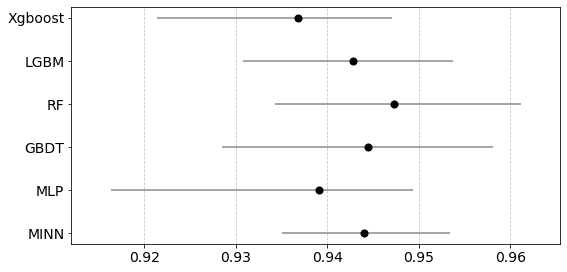

<Figure size 1800x1200 with 0 Axes>

In [41]:
# 使用示例
fig, ax = plot_single_metric_forest(
    df,           # 包含结果的数据框
    metric_col='AUROC',   # 要绘制的指标列名
    xlabel='', # 自定义x轴标签
    title='',
    colors={}, # 可选的模型颜色映射
    figsize = (10,4)
)
# 显示图形
plt.figure(dpi=300)
plt.show()

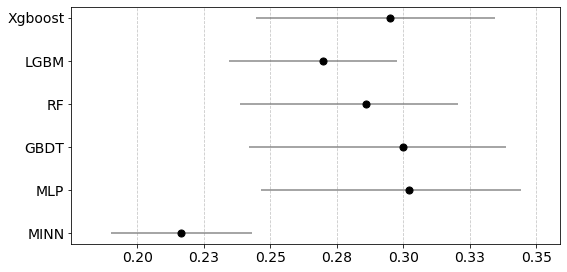

<Figure size 1800x1200 with 0 Axes>

In [42]:
# 使用示例
fig, ax = plot_single_metric_forest(
    df,           # 包含结果的数据框
    metric_col='AUPRC',   # 要绘制的指标列名
    xlabel='', # 自定义x轴标签
    title='',
    colors={}, # 可选的模型颜色映射
    figsize = (10,4)
)
# 显示图形
plt.figure(dpi=300)
plt.show()

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 定义任务和阶段
tasks = [
    "death_30d", 
    "have_icu", 
    "postop_stroke", 
    "postop_cardiac_complications", 
    "postop_lung_complications", 
    "have_aki", 
    "have_ali"
]

stages = ["preop", "postop"]

# 定义模型标签
model_labels = ["MINN", "MLP", "GBDT", "RF", "LGBM", "Xgboost"]

# 定义评分标签（仅用于preop阶段的death_30d任务）
score_labels = ["ASA", "CCI", "RCRI", "SORT"]

# 定义输入和输出路径
input_path = "/home/luojiawei/inspire_benchmark/results/pred_folder/"
output_path = "/home/luojiawei/inspire_benchmark/results/performance_folder/"
os.makedirs(output_path, exist_ok=True)

# 主循环
for stage in stages:
    for task in tasks:
        # 构建文件列表和标签列表
        current_file_list = []
        current_label_list = model_labels.copy()
        
        # 添加模型预测结果文件
        for model in model_labels:
            if model == "MINN":
                file_name = f"{task}_test_{stage}_minn.csv"
            elif model == "MLP":
                file_name = f"{task}_test_{stage}_mlp.csv"
            elif model == "GBDT":
                file_name = f"{task}_test_{stage}_gbdt.csv"
            elif model == "RF":
                file_name = f"{task}_test_{stage}_random_forest.csv"
            elif model == "LGBM":
                file_name = f"{task}_test_{stage}_lightgbm.csv"
            elif model == "Xgboost":
                file_name = f"{task}_test_{stage}_xgboost.csv"
            current_file_list.append(os.path.join(input_path, file_name))
        
        # 仅当处理 preop 阶段的 death_30d 任务时，添加评分文件
        if stage == "preop" and task == "death_30d":
            # 根据不同的评分系统使用正确的大小写
            for score in score_labels:
                if score == "CCI":
                    score_file = f"preop_CCI_score_death_30d.csv"
                elif score == "RCRI":
                    score_file = f"preop_RCRI_score_death_30d.csv"
                elif score == "ASA":
                    score_file = f"preop_asa_death_30d.csv"
                elif score == "SORT":
                    score_file = f"preop_sort_score_death_30d.csv"
                
                current_file_list.append(os.path.join(input_path, score_file))
                current_label_list.append(score)
        
        # 输出文件名前缀
        output_prefix = f"{stage}_{task}"
        
        # 读取数据
        print(f"处理任务: {output_prefix}")
        print(f"文件列表: {current_file_list}")
        print(f"标签列表: {current_label_list}")
        
        # 读取数据并计算结果
        datas = read_data_binary(current_file_list, current_label_list)
        results = compile_results_binary(datas, n_bootstraps=50)
        
        # 将结果字典转换为 DataFrame
        data_rows = []
        for model, metrics in results.items():
            row = {'model': model}
            for metric, (point_estimate, ci) in metrics.items():
                row[metric] = f"{point_estimate:.4f} ({ci[0]:.4f}, {ci[1]:.4f})"
            data_rows.append(row)

        df = pd.DataFrame(data_rows)
        
        # 重新排序列，确保 'model' 是第一列
        df = df[['model'] + [col for col in df if col != 'model']]
        
        # 保存性能数据
        result_output_path = f"{output_path}{output_prefix}.csv"
        df.to_csv(result_output_path, index=False)
        print(f"结果已保存到 {result_output_path}")
        
        # 绘制 AUROC 森林图
        fig_auroc, ax_auroc = plot_single_metric_forest(
            df,
            metric_col='AUROC',
            xlabel='',
            title='',
            colors={},
            figsize=(6, 4)
        )
        auroc_output_path = f"{output_path}{output_prefix}_AUROC.png"
        fig_auroc.savefig(auroc_output_path, bbox_inches='tight', dpi=300)
        plt.close(fig_auroc)
        print(f"AUROC 图已保存到 {auroc_output_path}")
        
        # 绘制 AUPRC 森林图
        fig_auprc, ax_auprc = plot_single_metric_forest(
            df,
            metric_col='AUPRC',
            xlabel='',
            title='',
            colors={},
            figsize=(6, 4)
        )
        auprc_output_path = f"{output_path}{output_prefix}_AUPRC.png"
        fig_auprc.savefig(auprc_output_path, bbox_inches='tight', dpi=300)
        plt.close(fig_auprc)
        print(f"AUPRC 图已保存到 {auprc_output_path}")
        
        print(f"已完成任务: {output_prefix}\n")

处理任务: preop_death_30d
文件列表: ['/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_minn.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_mlp.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_gbdt.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_random_forest.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_lightgbm.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_xgboost.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/preop_asa_death_30d.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/preop_CCI_score_death_30d.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/preop_RCRI_score_death_30d.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/preop_sort_score_death_30d.csv']
标签列表: ['MINN', 'MLP', 'GBDT', 'RF', 'LGBM', 'Xgboost', 'ASA', 'CCI', 'RCRI', 'SORT']


/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision /

结果已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_death_30d.csv
AUROC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_death_30d_AUROC.png
AUPRC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_death_30d_AUPRC.png
已完成任务: preop_death_30d

处理任务: preop_have_icu
文件列表: ['/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_minn.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_mlp.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_gbdt.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_random_forest.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_lightgbm.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_icu_test_preop_xgboost.csv']
标签列表: ['MINN', 'MLP', 'GBDT', 'RF', 'LGBM', 'Xgboost']


/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision /

结果已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_have_icu.csv
AUROC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_have_icu_AUROC.png
AUPRC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/preop_have_icu_AUPRC.png
已完成任务: preop_have_icu

处理任务: preop_postop_stroke
文件列表: ['/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_minn.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_mlp.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_gbdt.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_random_forest.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_lightgbm.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_stroke_test_preop_xgboost.csv']
标签列表: ['MINN', 'MLP', 'GBDT', 'RF', 'LGBM', 'Xgboost']


...

结果已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_cardiac_complications.csv
AUROC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_cardiac_complications_AUROC.png
AUPRC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_cardiac_complications_AUPRC.png
已完成任务: postop_postop_cardiac_complications

处理任务: postop_postop_lung_complications
文件列表: ['/home/luojiawei/inspire_benchmark/results/pred_folder/postop_lung_complications_test_postop_minn.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_lung_complications_test_postop_mlp.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_lung_complications_test_postop_gbdt.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_lung_complications_test_postop_random_forest.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/postop_lung_complications_test_postop_lightgbm.csv', '/home/luojiawei/inspire_benchma

/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision /

结果已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_lung_complications.csv
AUROC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_lung_complications_AUROC.png
AUPRC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_postop_lung_complications_AUPRC.png
已完成任务: postop_postop_lung_complications

处理任务: postop_have_aki
文件列表: ['/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_minn.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_mlp.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_gbdt.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_random_forest.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_lightgbm.csv', '/home/luojiawei/inspire_benchmark/results/pred_folder/have_aki_test_postop_xgboost.csv']
标签列表: ['MINN', 'MLP', 'GBDT', 'RF', 'LGBM', 'Xgboost']
结

/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:241: RuntimeWarning: invalid value encountered in true_divide
  2 * recall * precision /

结果已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_have_ali.csv
AUROC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_have_ali_AUROC.png
AUPRC 图已保存到 /home/luojiawei/inspire_benchmark/results/performance_folder/postop_have_ali_AUPRC.png
已完成任务: postop_have_ali



In [83]:
root_path = "/home/luojiawei/inspire_benchmark/results/pred_folder/"

file_list = ["mbp_test_intraop_minn.csv"]
label_list = ["MBP"]
file_list = [os.path.join(root_path, f) for f in file_list]

In [84]:
datas = read_data_multiclass(file_list, label_list, num_classes=3)

In [85]:
# roc_data, prc_data = compute_roc_prc_multiclass(datas)

In [86]:
class_name = ["Normal","Low","High"]
# plot_roc_prc_multiclass(roc_data, prc_data, num_classes = 3, data = datas, class_name = class_name)

In [87]:
results = compile_results_multiclass(datas, 3, 50)

/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:361: RuntimeWarning: invalid value encountered in true_divide
  f1_scores = np.where((recall + precision) > 0, 2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:361: RuntimeWarning: invalid value encountered in true_divide
  f1_scores = np.where((recall + precision) > 0, 2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:361: RuntimeWarning: invalid value encountered in true_divide
  f1_scores = np.where((recall + precision) > 0, 2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:361: RuntimeWarning: invalid value encountered in true_divide
  f1_scores = np.where((recall + precision) > 0, 2 * recall * precision / (recall + precision), 0)
/home/luojiawei/inspire_benchmark/modeling/utils_plot.py:361: RuntimeWarning: invalid value encountered in true_divide
  f1_scor

In [90]:
# 将多分类的结果字典转换为 DataFrame
data_rows = []
for model, classes in results.items():
    for class_label, metrics in classes.items():
        row = {'model': model, 'class': class_label}
        for metric, values in metrics.items():
            if isinstance(values, tuple):  # 检查是否为元组，即包含置信区间
                point_estimate, confidence_interval = values
                row[metric] = f"{point_estimate:.4f} ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})"
            else:
                row[metric] = f"{values:.4f}"
        data_rows.append(row)

df_multiclass = pd.DataFrame(data_rows)

# 如果你希望 'model' 和 'class' 是前两列，可以选择性地重新排序列
df_multiclass = df_multiclass[['model', 'class'] + [col for col in df_multiclass if col not in ['model', 'class']]]

In [91]:
df_multiclass

,model,class,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,Precision,F1
0,MBP,Class 0,"0.9524 (0.9518, 0.9528)","0.9958 (0.9957, 0.9958)","0.9380 (0.9377, 0.9386)","0.9783 (0.9768, 0.9798)","0.4649 (0.4453, 0.4840)","0.9555 (0.9540, 0.9570)","0.9667 (0.9665, 0.9671)"
1,MBP,Class 1,"0.9652 (0.9647, 0.9660)","0.6669 (0.6638, 0.6718)","0.9540 (0.9516, 0.9546)","0.7073 (0.7004, 0.7429)","0.9706 (0.9659, 0.9717)","0.6198 (0.5942, 0.6272)","0.6607 (0.6571, 0.6642)"
2,MBP,Class 2,"0.9556 (0.9541, 0.9571)","0.2847 (0.2778, 0.2915)","0.9762 (0.9743, 0.9784)","0.4853 (0.4441, 0.5225)","0.9837 (0.9813, 0.9866)","0.3139 (0.2976, 0.3336)","0.3812 (0.3749, 0.3886)"
3,MBP,Macro Average,"0.9577 (0.9525, 0.9648)","0.6491 (0.3038, 0.9793)","0.9560 (0.9388, 0.9750)","0.7236 (0.4964, 0.9647)","0.8064 (0.4902, 0.9830)","0.6297 (0.3292, 0.9387)","0.6696 (0.3952, 0.9514)"


In [92]:
df_multiclass.to_csv('/home/luojiawei/inspire_benchmark/results/performance_folder/intraop_test_minn_mbp.csv', index=False)

In [93]:
ds1 = pd.read_csv("/home/luojiawei/inspire_benchmark/results/pred_folder/mbp_test_intraop_minn.csv",header=0)
ds_op = pd.read_csv("/home/luojiawei/inspire_benchmark_data/operation_.csv",header=0)

In [94]:
ds1.loc[:5]

,op_id,time_point,y_true,y_pred_prob_0,y_pred_prob_1,y_pred_prob_2
0,400000790,2115.0,0,0.999310,2.226928e-05,0.000667
1,400000790,2120.0,0,0.999919,3.623518e-06,0.000077
2,400000790,2125.0,0,0.999969,1.906488e-06,0.000029
3,400000790,2130.0,0,0.999982,1.329595e-06,0.000017
4,400000790,2135.0,0,0.999987,1.062892e-06,0.000012
5,400000790,2140.0,0,0.999990,8.982659e-07,0.000009


In [95]:
ds_op.loc[:5,["op_id","orin_time","orout_time"]]

,op_id,orin_time,orout_time
0,400000455,1900,2005
1,400000790,2110,2235
2,400002668,1895,2020
3,400002811,3780,3930
4,400004042,1910,2115
5,400004062,2055,2190


In [96]:
import pandas as pd
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# 假设 ds1 和 ds_op 已经被正确加载
# 合并数据集
merged = pd.merge(ds1, ds_op, left_on='op_id', right_on='op_id')

# # 计算时间差
merged['time_from_start'] = merged['time_point'] - merged['orin_time']
merged['time_from_end'] = merged['time_point'] - merged['orout_time']


In [97]:
merged.iloc[:5]

,op_id,time_point,y_true,y_pred_prob_0,y_pred_prob_1,y_pred_prob_2,subject_id,hadm_id,case_id,opdate,...,postop_lung_complications,postop_cardiac_complications,postop_stroke,postop_maces,sort_score,CCI_score,RCRI_score,dataset,time_from_start,time_from_end
0,400000790,2115.0,0,0.999310,0.000022,0.000667,119508072,241502974,NaN,1440,...,0,0,0,0,0.0,0,1,2,5.0,-120.0
1,400000790,2120.0,0,0.999919,0.000004,0.000077,119508072,241502974,NaN,1440,...,0,0,0,0,0.0,0,1,2,10.0,-115.0
2,400000790,2125.0,0,0.999969,0.000002,0.000029,119508072,241502974,NaN,1440,...,0,0,0,0,0.0,0,1,2,15.0,-110.0
3,400000790,2130.0,0,0.999982,0.000001,0.000017,119508072,241502974,NaN,1440,...,0,0,0,0,0.0,0,1,2,20.0,-105.0
4,400000790,2135.0,0,0.999987,0.000001,0.000012,119508072,241502974,NaN,1440,...,0,0,0,0,0.0,0,1,2,25.0,-100.0


In [98]:
# 多分类情况的

# 使用新的函数计算带置信区间的指标
results_positive = {}
for t0 in range(0, 65, 5):
    filtered_data = merged[(merged['time_from_start'] > t0-5) & (merged['time_from_start'] <= t0 + 5)]
    (auroc, auroc_conf), (auprc, auprc_conf) = calculate_metrics_with_confidence(filtered_data, 'y_true', ['y_pred_prob_0', 'y_pred_prob_1', 'y_pred_prob_2'], 50)
    results_positive[t0] = {'AUROC': (auroc, auroc_conf), 'AUPRC': (auprc, auprc_conf)}

results_negative = {}
for t0 in range(0, -65, -5):
    filtered_data = merged[(merged['time_from_end'] < t0+5) & (merged['time_from_end'] >= t0 - 5)]
    (auroc, auroc_conf), (auprc, auprc_conf) = calculate_metrics_with_confidence(filtered_data, 'y_true', ['y_pred_prob_0', 'y_pred_prob_1', 'y_pred_prob_2'], 50)
    results_negative[t0] = {'AUROC': (auroc, auroc_conf), 'AUPRC': (auprc, auprc_conf)}



In [322]:
# 二分类情况的

# 使用新的函数计算带置信区间的指标
results_positive = {}
for t0 in range(0, 65, 5):
    filtered_data = merged[(merged['time_from_start'] > t0 - 5) & (merged['time_from_start'] <= t0 + 5)]
    (auroc, auroc_conf), (auprc, auprc_conf) = calculate_metrics_binary_with_confidence(filtered_data, 'y_true', 'y_pred_prob_0', 50)
    results_positive[t0] = {'AUROC': (auroc, auroc_conf), 'AUPRC': (auprc, auprc_conf)}

results_negative = {}
for t0 in range(0, -65, -5):
    filtered_data = merged[(merged['time_from_end'] < t0 + 5) & (merged['time_from_end'] >= t0 - 5)]
    (auroc, auroc_conf), (auprc, auprc_conf) = calculate_metrics_binary_with_confidence(filtered_data, 'y_true', 'y_pred_prob_0', 50)
    results_negative[t0] = {'AUROC': (auroc, auroc_conf), 'AUPRC': (auprc, auprc_conf)}


警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标
警告: 原始数据只有一个类别，无法计算指标


In [72]:
import pandas as pd

# 将 results_positive 转换为 DataFrame，并包括置信区间
df_positive = pd.DataFrame(list(results_positive.items()), columns=['Time from Start (minutes)', 'Metrics'])
df_positive[['AUROC', 'AUROC CI', 'AUPRC', 'AUPRC CI']] = pd.DataFrame(df_positive['Metrics'].apply(lambda x: [x['AUROC'][0], x['AUROC'][1], x['AUPRC'][0], x['AUPRC'][1]]).tolist(), index=df_positive.index)
df_positive.drop(columns=['Metrics'], inplace=True)

# 将 results_negative 转换为 DataFrame，并包括置信区间
df_negative = pd.DataFrame(list(results_negative.items()), columns=['Time to End (minutes)', 'Metrics'])
df_negative[['AUROC', 'AUROC CI', 'AUPRC', 'AUPRC CI']] = pd.DataFrame(df_negative['Metrics'].apply(lambda x: [x['AUROC'][0], x['AUROC'][1], x['AUPRC'][0], x['AUPRC'][1]]).tolist(), index=df_negative.index)
df_negative.drop(columns=['Metrics'], inplace=True)
df_negative.sort_values(by='Time to End (minutes)', inplace=True)


In [99]:
# 输出 DataFrame 到 CSV 文件
df_positive.to_csv('/home/luojiawei/inspire_benchmark/results/performance_folder/intraop_minn_mbp_1.csv', index=False)
df_negative.to_csv('/home/luojiawei/inspire_benchmark/results/performance_folder/intraop_minn_mbp_2.csv', index=False)


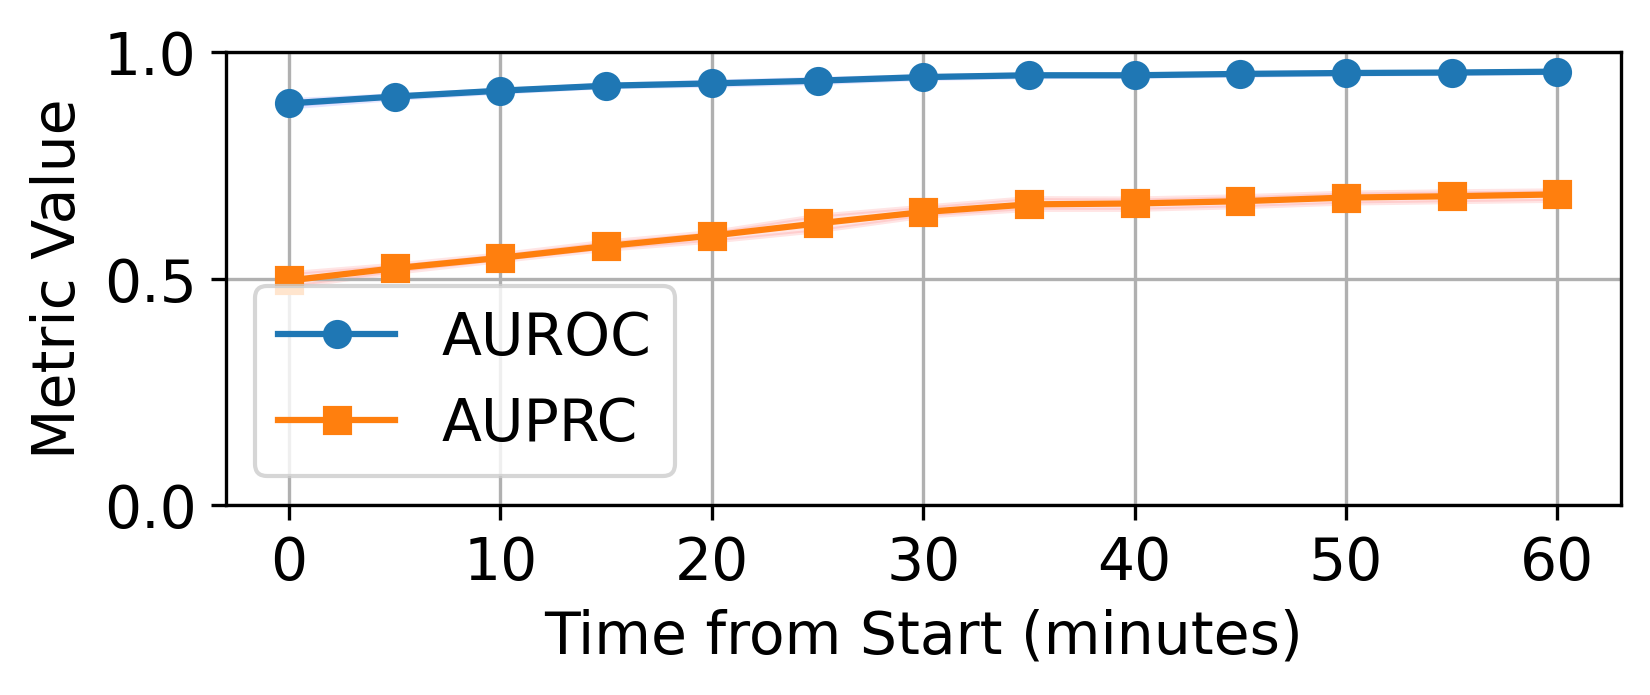

In [100]:
import matplotlib.pyplot as plt

# 绘制 results_positive
plt.figure(figsize=(6,2),dpi=300)
times = list(results_positive.keys())
auroc_values = [x['AUROC'][0] for x in results_positive.values()]
auroc_conf_intervals = [x['AUROC'][1] for x in results_positive.values()]
auprc_values = [x['AUPRC'][0] for x in results_positive.values()]
auprc_conf_intervals = [x['AUPRC'][1] for x in results_positive.values()]

# 绘制 AUROC 和其置信区间
plt.plot(times, auroc_values, marker='o', label='AUROC')
plt.fill_between(times, [ci[0] for ci in auroc_conf_intervals], [ci[1] for ci in auroc_conf_intervals], color='blue', alpha=0.1)

# 绘制 AUPRC 和其置信区间
plt.plot(times, auprc_values, marker='s', label='AUPRC')
plt.fill_between(times, [ci[0] for ci in auprc_conf_intervals], [ci[1] for ci in auprc_conf_intervals], color='red', alpha=0.1)

plt.xlabel('Time from Start (minutes)')
plt.ylabel('Metric Value')
plt.ylim(0, 1)  # 设置纵坐标范围为 0 到 1
plt.legend()
plt.grid(True)
plt.show()


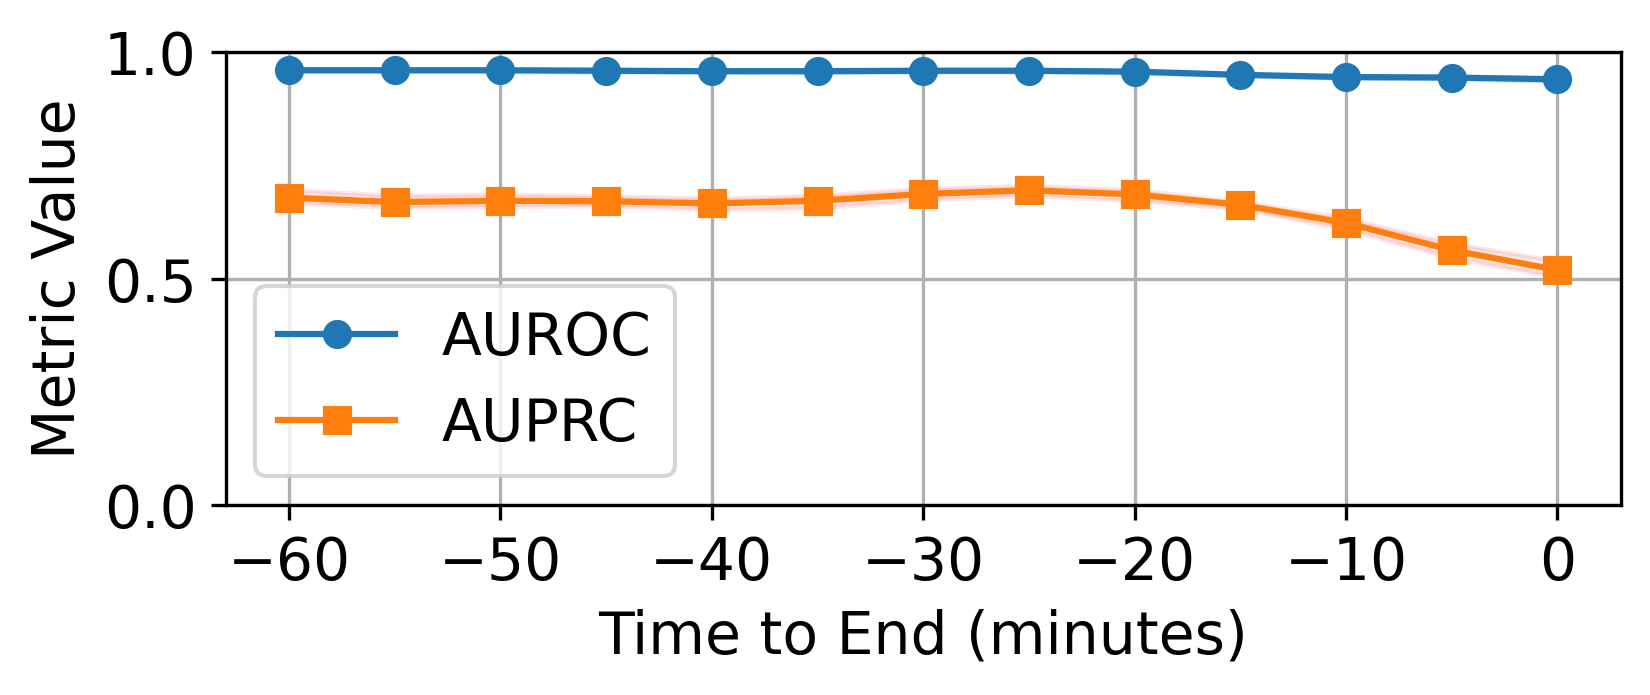

In [101]:
# 绘制 results_negative
plt.figure(figsize=(6,2),dpi=300)
# 注意：为了从 -60 开始画，我们需要对 keys 进行排序
negative_keys_sorted = sorted(results_negative.keys())
auroc_values = [results_negative[k]['AUROC'][0] for k in negative_keys_sorted]
auroc_conf_intervals = [results_negative[k]['AUROC'][1] for k in negative_keys_sorted]
auprc_values = [results_negative[k]['AUPRC'][0] for k in negative_keys_sorted]
auprc_conf_intervals = [results_negative[k]['AUPRC'][1] for k in negative_keys_sorted]

# 绘制 AUROC 和其置信区间
plt.plot(negative_keys_sorted, auroc_values, marker='o', label='AUROC')
plt.fill_between(negative_keys_sorted, [ci[0] for ci in auroc_conf_intervals], [ci[1] for ci in auroc_conf_intervals], color='blue', alpha=0.1)

# 绘制 AUPRC 和其置信区间
plt.plot(negative_keys_sorted, auprc_values, marker='s', label='AUPRC')
plt.fill_between(negative_keys_sorted, [ci[0] for ci in auprc_conf_intervals], [ci[1] for ci in auprc_conf_intervals], color='red', alpha=0.1)

plt.xlabel('Time to End (minutes)')
plt.ylabel('Metric Value')
plt.ylim(0, 1)  # 设置纵坐标范围为 0 到 1
plt.legend()
plt.grid(True)
plt.show()

In [120]:
import pandas as pd

In [102]:
ds = pd.read_csv( "/home/luojiawei/inspire_benchmark/results/pred_folder/death_30d_test_preop_minn.csv",header=0)
ds_op = pd.read_csv("/home/luojiawei/inspire_benchmark_data/operation_.csv",header=0).loc[:,["op_id","surgery_site"]]

In [103]:
ds.head()
# ds.shape

,op_id,y_true,y_pred_prob_0
0,400000790,0.0,0.000518
1,400009279,0.0,0.000751
2,400014671,0.0,0.000196
3,400024213,0.0,0.007437
4,400030331,0.0,0.000306


In [104]:
ds_op.head()

,op_id,surgery_site
0,400000455,Skin_and_Soft_Tissue
1,400000790,Urinary_and_Reproductive_Systems
2,400002668,Urinary_and_Reproductive_Systems
3,400002811,Other
4,400004042,Respiratory_System


In [108]:
# 合并数据集
merged_ds = pd.merge(ds, ds_op, how='left', left_on='op_id', right_on='op_id')


In [119]:
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

def calculate_metrics_with_confidence(data, y_true, y_score, group_by_column, n_bootstraps=1000, seed=123):
    results = {}
    grouped = data.groupby(group_by_column)
    
    for name, group in grouped:
        auroc_scores = []
        auprc_scores = []
        
        for _ in range(n_bootstraps):
            # Bootstrap sample
            sample = group.sample(n=len(group), replace=True, random_state=seed)
            try:
                auroc_scores.append(roc_auc_score(sample[y_true], sample[y_score]))
                auprc_scores.append(average_precision_score(sample[y_true], sample[y_score]))
            except ValueError as e:
                if 'Only one class present in y_true' in str(e):
                    print('Only one class present in y_true')
                    continue  # Skip this bootstrap sample if only one class is present
                else:
                    raise  # Re-raise the exception if it's not the expected "only one class" error
        
        # Calculate mean and 95% confidence intervals if scores were successfully added
        if auroc_scores and auprc_scores:
            auroc = np.mean(auroc_scores)
            auroc_conf = np.percentile(auroc_scores, [2.5, 97.5])
            auprc = np.mean(auprc_scores)
            auprc_conf = np.percentile(auprc_scores, [2.5, 97.5])
            
            results[name] = {
                'AUROC': (auroc, auroc_conf),
                'AUPRC': (auprc, auprc_conf)
            }
    
    return results


In [120]:
group_name = "surgery_site"
GN = "Surgery Site"
metrics_results = calculate_metrics_with_confidence(merged_ds, 'y_true', 'y_pred_prob_0', group_name, 50)

Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one class present in y_true
Only one c

In [121]:
metrics_results

{'Bones_and_Joints': {'AUROC': (0.9636425673882549,
   array([0.96364257, 0.96364257])),
  'AUPRC': (0.25392316367260476, array([0.25392316, 0.25392316]))},
 'Central_Nervous_System_and_Cranial_Nerves': {'AUROC': (0.8915662650602411,
   array([0.89156627, 0.89156627])),
  'AUPRC': (0.07692903957460541, array([0.07692904, 0.07692904]))},
 'Gastrointestinal_System': {'AUROC': (0.9240853062023087,
   array([0.92408531, 0.92408531])),
  'AUPRC': (0.21452370382521618, array([0.2145237, 0.2145237]))},
 'Head_and_Neck': {'AUROC': (0.9944168734491317,
   array([0.99441687, 0.99441687])),
  'AUPRC': (0.14285714285714285, array([0.14285714, 0.14285714]))},
 'Heart_and_Great_Vessels': {'AUROC': (0.9398395721925132,
   array([0.93983957, 0.93983957])),
  'AUPRC': (0.18927404334102904, array([0.18927404, 0.18927404]))},
 'Hepatobiliary_System_and_Pancreas': {'AUROC': (0.9933386624034106,
   array([0.99333866, 0.99333866])),
  'AUPRC': (0.375, array([0.375, 0.375]))},
 'Other': {'AUROC': (0.96438327

In [122]:
surgery_site_counts = merged_ds['surgery_site'].value_counts()
surgery_site_counts

Head_and_Neck                                3227
Urinary_and_Reproductive_Systems             3204
Skin_and_Soft_Tissue                         2687
Gastrointestinal_System                      2171
Bones_and_Joints                             2042
Other                                        1367
Hepatobiliary_System_and_Pancreas            1254
Endocrine_System                              946
Central_Nervous_System_and_Cranial_Nerves     918
Respiratory_System                            906
Peripheral_Vascular_System                    660
Heart_and_Great_Vessels                       555
Lymphatic_and_Hemic_Systems                   322
Name: surgery_site, dtype: int64

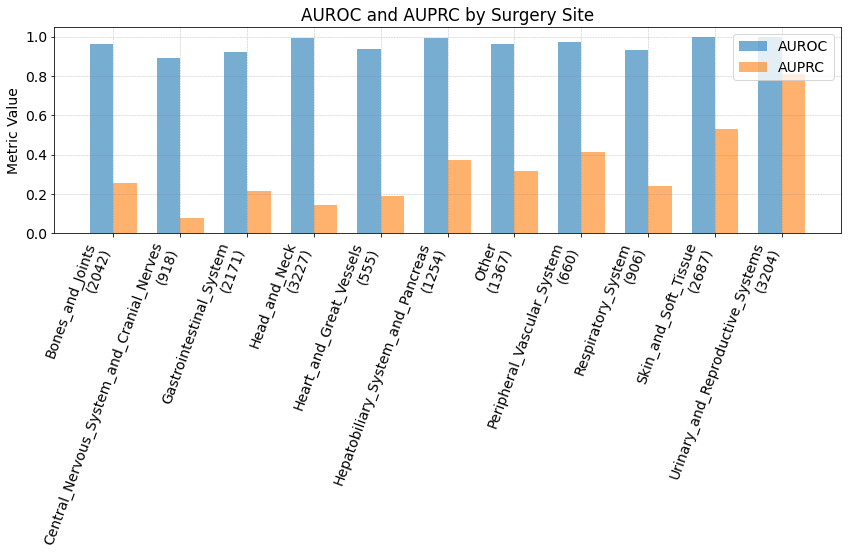

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# 设置字体为 DejaVu Sans
plt.rcParams['font.family'] = 'DejaVu Sans'

# 绘制图表
fig, ax = plt.subplots(figsize=(12, 8))

type_names = list(metrics_results.keys())
auroc_values = [metrics_results[name]['AUROC'][0] for name in type_names]
auprc_values = [metrics_results[name]['AUPRC'][0] for name in type_names]

# 计算每个 ASA 类型的样本量
type_counts = merged_ds[group_name].value_counts().sort_index()

# 生成包含样本量的 type_names
type_names = [f"{x}\n({count})" for x, count in zip(metrics_results.keys(), type_counts.reindex(metrics_results.keys()).fillna(0).astype(int))]

# 设置柱子的宽度和位置
bar_width = 0.35  # 柱子的宽度
index = np.arange(len(type_names))  # type_names 的索引数组

# 绘制柱状图
rects1 = ax.bar(index - bar_width/2, auroc_values, bar_width, label='AUROC', alpha=0.6)
rects2 = ax.bar(index + bar_width/2, auprc_values, bar_width, label='AUPRC', alpha=0.6)

ax.set_ylabel('Metric Value')
ax.set_title(f'AUROC and AUPRC by {GN}')
ax.set_xticks(index)
ax.set_xticklabels(type_names, ha='right')  # 设置 x 轴标签的对齐方式为右对齐
ax.legend()

# 添加灰色的网格线
ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [112]:
# 将 metrics_results 转换为 DataFrame 并保存到 CSV 文件
metrics_df = pd.DataFrame([
    {
        'Group': group,
        'AUROC': f"{metrics['AUROC'][0]:.4f} ({metrics['AUROC'][1][0]:.4f}, {metrics['AUROC'][1][1]:.4f})",
        'AUPRC': f"{metrics['AUPRC'][0]:.4f} ({metrics['AUPRC'][1][0]:.4f}, {metrics['AUPRC'][1][1]:.4f})"
    }
    for group, metrics in metrics_results.items()
])


In [113]:
metrics_df

,Group,AUROC,AUPRC
0,Bones_and_Joints,"0.9703 (0.9444, 0.9888)","0.3259 (0.1596, 0.4846)"
1,Central_Nervous_System_and_Cranial_Nerves,"0.8716 (0.7430, 0.9799)","0.1047 (0.0290, 0.2921)"
2,Gastrointestinal_System,"0.9070 (0.8340, 0.9696)","0.2238 (0.0650, 0.3998)"
3,Head_and_Neck,"0.9862 (0.9681, 0.9962)","0.0798 (0.0097, 0.2038)"
4,Heart_and_Great_Vessels,"0.9532 (0.9269, 0.9848)","0.3127 (0.1303, 0.6550)"
5,Hepatobiliary_System_and_Pancreas,"0.8718 (0.5108, 0.9947)","0.1646 (0.0061, 0.3730)"
6,Other,"0.9684 (0.9500, 0.9821)","0.3439 (0.1738, 0.5413)"
7,Peripheral_Vascular_System,"0.9054 (0.7947, 0.9851)","0.3466 (0.0611, 0.6577)"
8,Respiratory_System,"0.8925 (0.8120, 0.9583)","0.3682 (0.1543, 0.5366)"
9,Skin_and_Soft_Tissue,"0.9944 (0.9902, 0.9976)","0.4099 (0.2183, 0.7198)"


In [271]:
metrics_df.to_csv("/home/luojiawei/pengxiran_project/结果文件夹/性能表格/subgroup_analysis_with_surg_in_hospital_death_post.csv", index=False)